![](figures/Header.png)

# TP1

The first practical work is dedicated to descriptive statistics on vegetation cover. The data basis will be  satellite data and a digital elevation model. The regions of investigation are in the Jura and the pre-Alps around Fribourg. At the end of this course, students should illustrate and discuss (short discussion towards the end of their notebook) differences of NDVI between years, elevation, exposition and land use. This will be only descriptive. This exercise directly prepares for next week, where we will test whether differences are statistically significant.

In short, the aims are:
- Read raster data
- Understand structure (how to select pixels using conditional operators)
- Quantify regional vegetation health/intensity
- Graphical representation of this quantification
    - Plotting maps
    - Histogram of (continuous - not categorical!) data over a spatial domain
    - Boxplots to identify the distribution of values
- Incorporation of supporting information (elevation, exposition, land use) to show how this affects the vegetation


## Geospatial satetellite data on vegetation changes

The normalized differences vegetation index (NDVI) is showing how "green & healthy" the vegetation is on the Earth surface. It is calculated using multi-spectral (not just Red, Green, and Blue) bands - the intensities of electromagnetic waves in specific wavelengths. These wavelengths are the ones for **red** and **infrared** light. Plant chlorophyll absorbs red light, and emits infrared light during the photosynthesis. The NDVI is an easy way to assess how healty/thick the vegetation cover is and it allows to compare different years to spot how, e.g. extreme weather has affected the vegetation growth.

The formula for the NDVI is:

$$NDVI={\frac {(NIR - red)}{(NIR + red)}},$$

where NIR means near-infrared. The index is normalized to the combined intensity of NIR and red light $(NIR + red)$, so that the maximum value is $1$ for complete/healthy vegetation cover. 

![ndvi](figures/Indice-vegetativo-NDVI.jpg)

*Figure1: Reflectance and emittance from leafs with different health.*

## NDVI data sources

The NDVI can be calculated from any multispectral dataset (e.g. Landsat, MODIS). The NDVI can also be obtained as already calculated product, e.g. based on MODIS (MODerate resolutIon Spectroradiometer), an instrument mounted on the two NASA satellites Aqua and Terra.

These datasets come in **specific geospatial data formats**, like GeoTiff or netCDF (network Common Data Format). These data formats are designed to store all geospatial information like **where** is a datapoint, **what projection** has the data, and the data formats also compresses information in a very efficient way so that files of this data format need less disk space.


## External libraries
External libraries are user-made collections of drivers and methods to expand the functionality of `Python`. These can be installed in `Anaconda` with the `conda install <package name>` command, where `<package-name>` stands for the package to be installed, e.g. "`matplotlib`". 

> On renkulab, we have **pre-installed all packages** that we will be using during the course!

These libraries need to be loaded into our programs/scripts to be available to `Python`. This is done with the command `import <package name>` or `from <package name> import <module name>`. If you try to load a package that is not installed you will receive an error message.

In [1]:
# An example of loading a libary
import xarray
# An example of loading a libary with an "alias" (an abbreviation for lazyness)
import numpy as np

# An example of loading a single module from a libary
from matplotlib import pyplot
# An example of loading a single module from a libary with an alias
from matplotlib import pyplot as plt

## Datasets

### NDVI

We will use the MODIS dataset on NDVI with the name **MOD13Q1**, which is a composite of multiple scenes recorded over a period of 16 days. The data has been prepared, i.e. **reprojected** from its original projection (sinusoidal) to the Universal Transverse Mercator **(UTM) Zone 32N** projection, and to a **spatial resolution of 250 m**. The dataset has multiple layers in its original format and we have chosen the layer that contains just the pre-calculated NDVI data. You will find the data in the file format "GeoTiff", i.e. files with ending **".tif"**. The data are cropped to the regions of the Jura and the pre-Alps around Fribourg (see Figure 2). The `xarray`-package contains the drivers to open these files and access the data. The raster data is stored as a variable of object type `xarray.DataSet`. The files are contained in the "data" folder, located in home directory in your renkulab environment. In the examples below ([Loading-Multiple-datasets](#Loading-multiple-datasets)), you can see how the file path is provided to the `xarray` function that opens the data link. You have multiple years available (2015-2018).

Important notes:
- The NDVI data is saved in `integer` format to save disk space (better than float) using a **scaling factor**
- We need to multiply the data with the inverse of that scaling factor
    - For MOD13Q1 the scaling factor is $10^{4}$
    - Different datasets have different scaling factors
    - Most modern datasets use modern file formats (like netcdf, HDF5) that **automatically** apply scaling factors when opening the file

![](figures/overview_map_TP1.png)

*Figure 2: Extents of the prepared datasets in the Jura and the pre-Alps around Fribourg*



### Digital Elevation Model (DEM)
The SwissTopo DHM25 (https://www.swisstopo.admin.ch/en/products-applications/dhm25.html) dataset is used to create two DEMs for the two regions. The DEMs will serve to select data based on the altitude. The data was also reprojected to the UTM 32N projection and to a spatial resolution of 250m to match the NDVI dataset.

### Aspect
The aspect, i.e. the surface orientation in degrees, was derived from the DEMs using QGIS. The aspect can be incorporated for advanced students to extend the level of complexity and refine the classes of interest.

### Land cover
A pre-classified land cover map is provided to allow for comparison of NDVIs that belong to different vegetation types, like forests or croplands. The dataset used is MODIS MCD12Q1. The classification results from a supervised classification algorithm according to the FAO-Land Cover Classification System (LCCS2 - https://lpdaac.usgs.gov/documents/101/MCD12_User_Guide_V6.pdf Table 9). The classes are the dominant classes over the period of an entire year and we chose the classification from the year 2017.



## Process chain
In the following you can see the individual steps with working examples on how to 
- **open** files
- **view information** about the datasets
- **perform logical/conditional operations**
- select data based on **conditional operations**

### Opening and accessing data

In [2]:
import xarray as xr

# In our case, we apply for the NDVI values a scaling factor to transform the stored values (integer) to floating point numbers
scaling_factor = 1 / 10**4

filename_ndvi_2015 = "../../data/MODIS/fribourg/MOD13Q1.A2015225.006.250m 16 days NDVI.r32632_fribourg.tif"
ndvi_2015_dataset = xr.open_dataset(filename_ndvi_2015) * scaling_factor

#### Explanation:
- `import xarray as xr` loads the package to handle the raster data with an alias "xr".
- `xr.open_dataset()` is the function to open the dataset; it requires 1 argument, namely the filename.
- `* scaling_factor` directly multiplies the dataset (all available **bands** with the value of scaling_factor).

#### Structure of an xarray.DataSet
The following code cell calls the variable `ndvi_2015_dataset`. The output shows the structure of this dataset. The key features are that there are **dimensions**, **coordinates**, and **variables**:
- Dimensions:
  - `x`
  - `y`
  - `band` - which layer (in case of multiple raster layers in a single file; here 1)
- Coordinates:
  - `x` (actual values in x-direction)
  - `y` (actual values in y-direction)
  - `band` (in case of multiple raster layers in a single file; here 1)
- Variables (Data variables)
  - `band_data` (generic name of the data layer; instead of "NDVI")


In [3]:
ndvi_2015_dataset

<xarray.Dataset> Size: 232kB
Dimensions:      (band: 1, x: 218, y: 262)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 2kB 3.406e+05 3.409e+05 ... 3.946e+05 3.949e+05
  * y            (y) float64 2kB 5.208e+06 5.208e+06 ... 5.143e+06 5.143e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 228kB 0.834 0.8328 0.876 ... 0.4775 0.5962

#### xarray.DataArray 
The actual data are stored in an `array` (a matrix) representing the NDVI value for each pixel. Keeping the object type as `xarray.DataArray`, rather than a `numpy` numerical matrix, is advantegeous. This is because it allows us to have access to the `xarray` processing algorithms, mathematical operations (also combining different datasets), and it gives us access to all the plotting functions that are inherent to any `xarray` object. 

#### Selecting the data layer
The data layer (`xarray.DataArray`) can simply be selected via the name that we can see under "Data variable", in our example this layer has the name `band_data`.

In [4]:
# the layer of interest, now stored as xarray.DataArray
ndvi_2015 = ndvi_2015_dataset.band_data

In [5]:
ndvi_2015

<xarray.DataArray 'band_data' (band: 1, y: 262, x: 218)> Size: 228kB
array([[[0.834     , 0.8328    , 0.876     , ..., 0.7973    ,
         0.76629996, 0.78249997],
        [0.7973    , 0.7973    , 0.4965    , ..., 0.8272    ,
         0.79639995, 0.82339996],
        [0.7479    , 0.51129997, 0.51129997, ..., 0.80399996,
         0.8038    , 0.871     ],
        ...,
        [0.825     , 0.85649997, 0.90599996, ..., 0.60469997,
         0.77779996, 0.81759995],
        [0.67039996, 0.78419995, 0.84129995, ..., 0.64599997,
         0.6766    , 0.81759995],
        [       nan, 0.65029997, 0.8149    , ..., 0.6921    ,
         0.4775    , 0.5962    ]]], shape=(1, 262, 218), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 2kB 3.406e+05 3.409e+05 ... 3.946e+05 3.949e+05
  * y            (y) float64 2kB 5.208e+06 5.208e+06 ... 5.143e+06 5.143e+06
    spatial_ref  int64 8B ...

In [6]:
# Alternatively, similar to a pandas.DataFrame, this layer can be selected using the writing: <object name>["Layer name"]

# You can remove the comment "#" from the next line and execute the cell. You will see the output is the same as before
# ndvi_2015_dataset["band_data"]

#### Values
If we only need the values, e.g. when trying to make a boxplot, or scatterplot, we can extract the data as follows:
- `<DataArray>.values` - provides **only** the matrix (array) without any of the spatial information

In [7]:
ndvi_2015.values

array([[[0.834     , 0.8328    , 0.876     , ..., 0.7973    ,
         0.76629996, 0.78249997],
        [0.7973    , 0.7973    , 0.4965    , ..., 0.8272    ,
         0.79639995, 0.82339996],
        [0.7479    , 0.51129997, 0.51129997, ..., 0.80399996,
         0.8038    , 0.871     ],
        ...,
        [0.825     , 0.85649997, 0.90599996, ..., 0.60469997,
         0.77779996, 0.81759995],
        [0.67039996, 0.78419995, 0.84129995, ..., 0.64599997,
         0.6766    , 0.81759995],
        [       nan, 0.65029997, 0.8149    , ..., 0.6921    ,
         0.4775    , 0.5962    ]]], shape=(1, 262, 218), dtype=float32)

In various functions we need the data either as a `list` or as a **1D** `array`. This is achieved by adding the `.flatten()` function:

In [8]:
ndvi_2015.values.flatten()

array([0.834 , 0.8328, 0.876 , ..., 0.6921, 0.4775, 0.5962],
      shape=(57116,), dtype=float32)

#### Loading multiple datasets
You can check the different datasets inside the folders `/data/MODIS/fribourg/` and `/data/MODIS/jura/`. The main `data` folder is located inside `geoscience-unifr-py/`.

In [9]:
# --- Imports ---
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- File paths ---
filename_ndvi_2015 = "../../data/MODIS/fribourg/MOD13Q1.A2015225.006.250m 16 days NDVI.r32632_fribourg.tif"
filename_ndvi_2016 = "../../data/MODIS/fribourg/MOD13Q1.A2016225.006.250m 16 days NDVI.r32632_fribourg.tif"
filename_dem = "../../data/MODIS/fribourg/DEM_250m_fribourg.tif"  # digital elevation model
filename_lc = "../../data/MODIS/fribourg/MCD12Q1_2017_LC_Prop2_fribourg.tif"  # landuse classification

# Scaling factor needed for the NDVI values
scaling_factor = 1 / 10**4

# --- Load raster datasets with xarray ---
ndvi_2015_dataset = xr.open_dataset(filename_ndvi_2015) * scaling_factor
ndvi_2016_dataset = xr.open_dataset(filename_ndvi_2016) * scaling_factor
lc_2017_dataset = xr.open_dataset(filename_lc)  # no scaling factor here!
dem_dataset = xr.open_dataset(filename_dem)  # no scaling factor here!

# --- Select the required layer AND reduce dimension (remove layer dimension) ---
ndvi_2015 = ndvi_2015_dataset.band_data.squeeze()  # the .squeeze() function reduces the dimensions to 2D (see explanation about "dimensions" below)
ndvi_2016 = ndvi_2016_dataset.band_data.squeeze()
lc_2017 = lc_2017_dataset.band_data.squeeze()
dem = dem_dataset.band_data.squeeze()

### View information about the datasets
Getting the meta data (data description), fast and without reading these pieces of information manually (examples above), can be done as follows:
- spatial resolution --> `<DataSet or DataArray>.rio.resolution()`
  - `.rio` stands for "raster input/output"
  - `.rio` has an inherent function (`.resolution()`) to get the spatial resolution. The negative value indicates that the **y**-coordinate is decreasing because the counting starts in the top right corner --> Latitudes or Northing (UTM coordinate system) are decreasing the further south we go, hence the negative sign.
- spatial reference system --> `<DataSet or DataArray>.rio.crs`
  - `.crs` stands for "coordinate reference system"
- dimensions --> `<DataArray>.shape`
  - `.shape` displays how many rows and columns the matrix (only `xarray.DataArray`) has. `.shape` is a property (not a function).
  - Note that we get **three** values:
    - `(1, 262, 218)`: the first indicates how many layers we have. Since we only have one layer, namely the NDVI value layer, we have the `1`.
    - This can be **problematic** when applying mathematical functions that are expecting **2D** matrices.
    - Use the `.squeeze()` function to reduce the number of dimensions to "what makes sense"; in our case this eliminates the first (how many layers) dimension.
  - `.size` displays number of pixels

#### Try the different functionalities in the cell below:

In [10]:
# ndvi_2015_dataset.rio.crs
# ndvi_2015.shape vs ndvi_2015.squeeze().shape
# try the different ways to display the information yourself...

### Perform logical/conditional operations

We can test if certain pixels fulfill a requirement, e.g. if they are greater or smaller a certain value. The resulting `logical` (boolean: `True` or `False`) result can be used to select these pixels and perform additional operations.

This logical "mask" is generated using the `.where()` function. Inside this function, you can also use a different raster (if the two rasters are aligning perfectly). This allows for a logical operation on one raster, and using the result to select pixels of a different raster. In the following some examples to select pixels of raster A (`<rasterA>`):
```
<rasterA>.where(<rasterB> CONDITION)
```
or on the same raster:
```
<rasterA>.where(<rasterA> CONDITION)
```
and with multiple conditions:
```
<rasterA>.where((<rasterA> CONDITION) & (or |) (<rasterX> CONDITION))
```
The result is also an `xarray` object where every pixel (of `<rasterA>` is set to `NaN` (not a number), where the condition was **not** met. 

***Note:*** You can use the **opposite** of a condition by "negating" it using the `~` symbol. An example is to find all values that are actual values and not NaN. The following example checks if the values are "not NaN (~np.isnan())":
```
rasterA.where(~np.isnan(rasterA))
```
***

Each raster dataset is organized as a matrix, with an individual value for each matrix element (pixel). We can use various operations to analyse the data. Some examples are:

- How many pixels show a certain value (e.g. how many pixels have a NDVI > x, or how many pixels are landuse class **y**)?
- What are the percentages of certain landuse classes?
- How different are the NDVI values between different landuse classes (combining landuse and NDVI datasets)?
- What is the difference in NDVI between certain altitude bands (combining NDVI and DEM)?
- What is the difference in NDVI between different years (combining multiple NDVI datasets)?

The following shows some examples on how to perform the analyses and how to combine different datasets. The code uses the already loaded [datasets](#Loading-multiple-datasets).

#### Examples I
##### How many pixels show a certain value (e.g. how many pixels have a NDVI > x, or how many pixels are landuse class y)?
Explanation:
- `ndvi_2015_gr05` is a boolean DataArray (`True/False` for the logical operation `> 0.5`, for each pixel)
-  `ndvi_2015_gr05.sum()` takes the sum of all these `True` or `False` values. Because `True` has the value 1, and `False` has the value 0, the sum gives us the number of pixels where the logical operation `> 0.5` was true.

In [11]:
ndvi_2015_gr05 = ndvi_2015 > 0.5
ndvi_2015_gr05.sum() 

<xarray.DataArray 'band_data' ()> Size: 8B
array(53000)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B ...

##### What are the percentages of certain landuse classes?
If you look into Table 9 of the dataset description document for MODIS [MCD12Q1](#Land-cover), you can see that e.g. "Natural Herbaceous" has the landuse class `30`. We can identify how many pixels of that class exist and divide this value by the total number of pixels. For a percentage multiply this value with 100.

Explanation:
- `lc_class30` is a boolean DataArray where the landuse class equals the value 30 (natural herbaceous).
- `lc_class30.sum() / lc_2017.size` is the ratio of those pixels compared to the total amount of pixels in the raster
- `* 100` derives the percentage

In [12]:
lc_class30 = lc_2017 == 30
lc_class30.sum() / lc_2017.size * 100
# note that the results is still a xarray.DataArray. To only get the value, save the result as a new variable (<variable>),
# and then use <variable>.values

<xarray.DataArray 'band_data' ()> Size: 8B
array(23.30520345)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B ...

##### How different are the NDVI values between different landuse classes (combining landuse and NDVI datasets)?
This requires combining different datasets. As all datasets have the same spatial extent, and resolution, they align perfectly. This allows for applying logical operations on one dataset and using the boolean "mask" on another dataset.

The key function is here the `where()` function:
- `<xarray.DataArray>.where()` allows us to remove all values where our logical operation or condition is not met.

In the example below, the `.where()` function is used to remove all values in the DEM, where the elevation is lower than 1500 m.

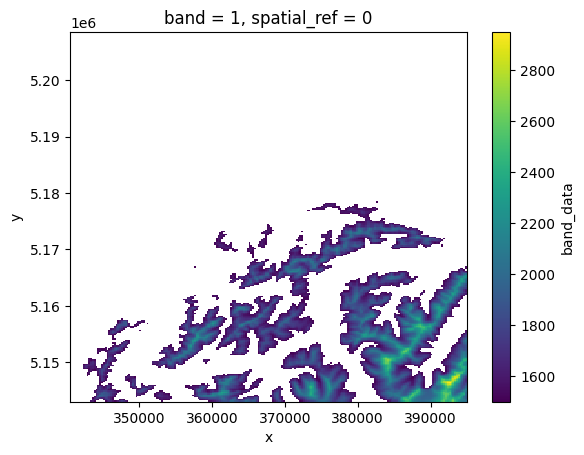

In [13]:
dem_gr1500m = dem.where(dem > 1500)
dem_gr1500m.plot()

The `.where()` is applied on one dataset but the condition can be based on another dataset.
In the example below, `.where()` is applied on the NDVI from 2015 (`ndvi_2015`), but the condition is based on the elevation (`dem`):

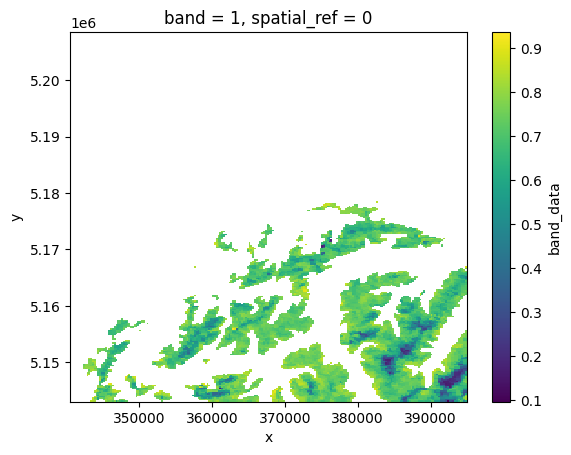

In [14]:
ndvi_2015_gr1500m = ndvi_2015.where(dem > 1500)
ndvi_2015_gr1500m.plot()

Now for the landuse example:
- Use `.where()` on the NDVI
- Set the condition so that landuse must be class 30

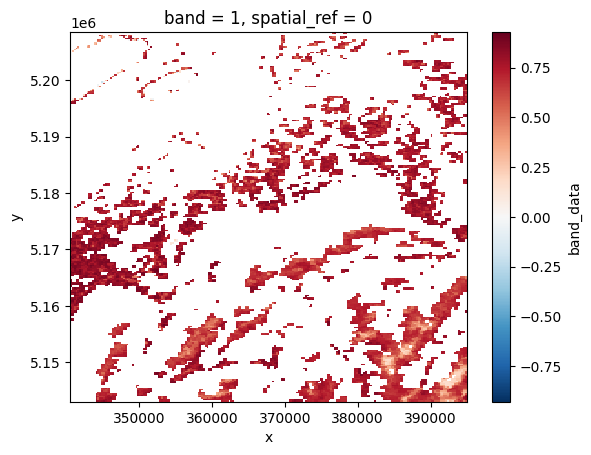

In [15]:
ndvi_2015_lc30 = ndvi_2015.where(lc_2017 == 30)
ndvi_2015_lc30.plot()

#### Using `.where()` and multiple conditions
The `.where()` function can also be used with multiple conditions. It is important to separate each condition first by using parentheses "`()`", and to use the logical combination symbols "and" or "or":
- OR `|`
- AND `&`

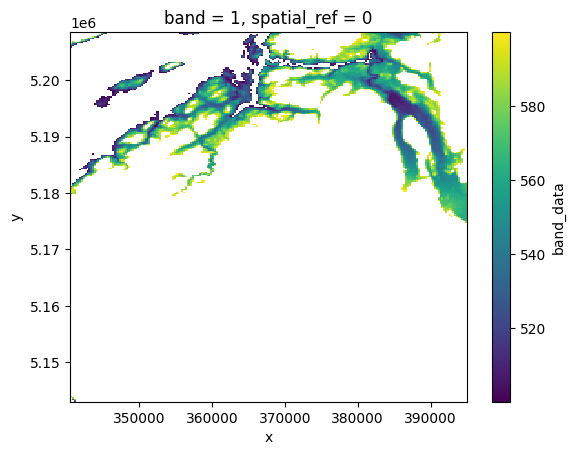

In [16]:
dem_100to400m = dem.where((dem > 500) & (dem < 600))
dem_100to400m.plot()

### Plotting
The `xarray` package provides directly map plotting functions, accessible via `<xarray.DataArray>.plot()`. There are various possibilities to adjust the appearance of the plots, including changing color schemes, adjust axes labels, etc.

In the following you will see several examples:

In [17]:
# --- Define your own color maps ---
from matplotlib.colors import ListedColormap

div_colors_ndvi = ListedColormap(["brown", "yellow", "green", "darkgreen"])
# div_colors_ndvi = ListedColormap(["#660000", "#777700", "#AACC00","#00FF00", "#008800"])
div_colors_diff = ListedColormap(["#990000", "white", "#009900"])

# or use any of the various pre-defined colormaps in the matplotlib library:
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#choosing-colormaps-in-matplotlib
# These can be used inside the plot function with their abbreviated text string (e.g. "viridis", "PuOr", ...) 
# for the argument "cmap="; see examples below.

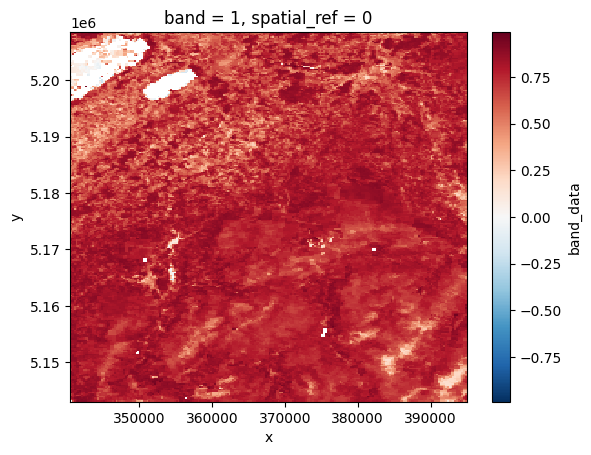

In [18]:
# --- base plotting function in the package xarray ---
ndvi_2015.plot()

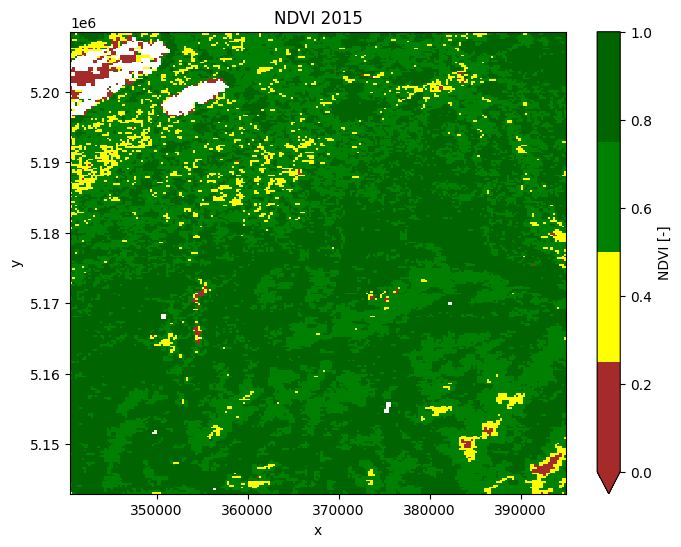

In [19]:
# --- adjust plotting arguments ---
fig, ax = plt.subplots(figsize=(8, 6))   # Create matplotlib figure as a basis
ndvi_2015.plot(                          # run the .plot() function
    ax=ax,                               # the "ax" argument links this plot to the matplotlib figure (see the "ax" in fig,ax = ...)
    cmap=div_colors_ndvi,                # the color map (cmap) are the colors to be used
    vmin=0,                              # the value to be used as minimal value for the colors
    vmax=1,                              # the value to be used as maximum value for the colors
    cbar_kwargs={"label": "NDVI [-]"}    # label of the "color bar" (on the right-hand side
)
ax.set_title("NDVI 2015")                # figure title
# ax.axis("off")                         # turns of axes if desired
plt.show()                               # forces displaying 

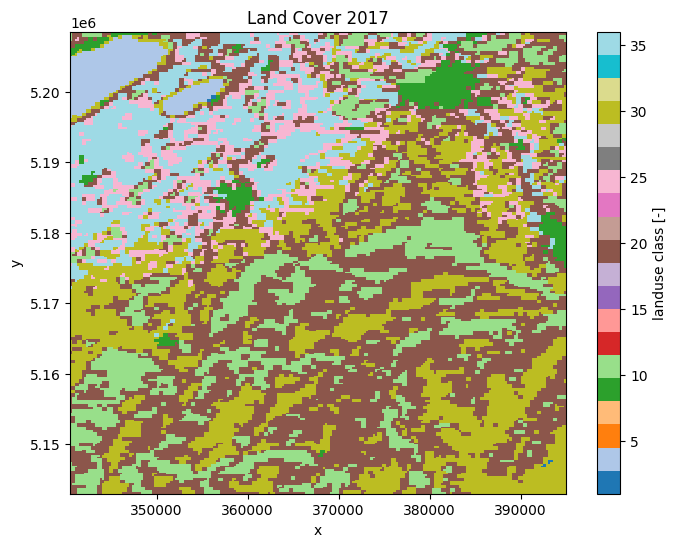

In [20]:
# --- Land Cover 2017 ---
fig, ax = plt.subplots(figsize=(8, 6))
lc_2017.plot(ax=ax,
             cmap="tab20",
             cbar_kwargs={"label": "landuse class [-]"}
            )
ax.set_title("Land Cover 2017")
plt.show()

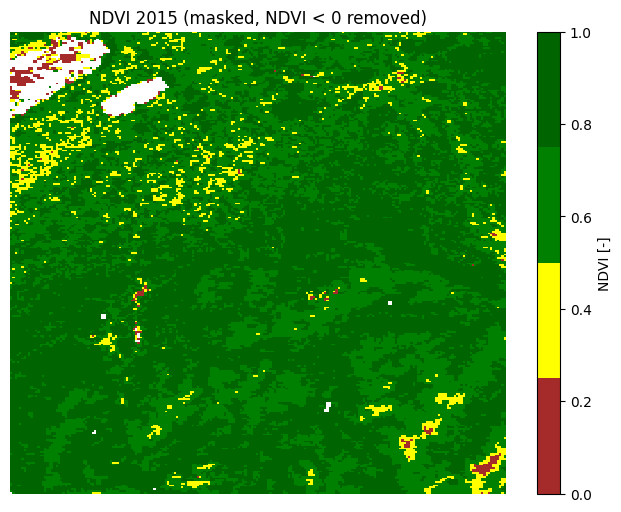

In [21]:
# --- Mask NDVI values < 0 ---
ndvi_2015_masked = ndvi_2015.where(ndvi_2015 >= 0)

fig, ax = plt.subplots(figsize=(8, 6))
ndvi_2015_masked.plot(
    ax=ax,
    cmap=div_colors_ndvi,
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "NDVI [-]"}
)
ax.set_title("NDVI 2015 (masked, NDVI < 0 removed)")
ax.axis("off")
plt.show()

#### Histogram and Boxplot
Both plotting types require a list or 1D array as input data. This is achieved by reducing the `xarray.DataArrays` to 1D numpy arrays:
- `<xarray.DataArray>.values.flatten()` - produces a 1D `numpy` array.

In the Boxplot, only numerical values are allowed. Therefore, all values that are not a number "NaN" are removed:
- `dem.values.flatten()[~np.isnan(dem.values.flatten())`
  - `dem.values.flatten()` are all the values (including NaN values that need to be removed)
  - `np.isnan()` is a function that returns a boolean array, with `True` if a value was NaN and `False` if not
  - `~` reads as **"is not"**
    - `~np.isnan()` therefore looks for values that are **not NaN**
  - `~np.isnan(dem.values.flatten())` therefore looks for all valid values inside `dem` and returns a boolean (True/False) array. This array can be used as indices with another numpy array. This is indicated by the `[ ]` after the flattened `dem.values` array:
  - `dem.values.flatten()[~np.isnan(dem.values.flatten())]` --> returns all `dem` values as 1D array, where `dem` has numerical (not NaN) values.
- Alternatively, but with three lines of code, this might look easier to understand:
```
masked_dem = dem.where(dem > -9999)
dem_values = masked_dem.values.flatten()
axes[1].boxplot(dem_values)
```
   - Here the `.where()` function returns a `False` for all non-numeric (e.g. NaN) values (BUT also for values smaller -9999)

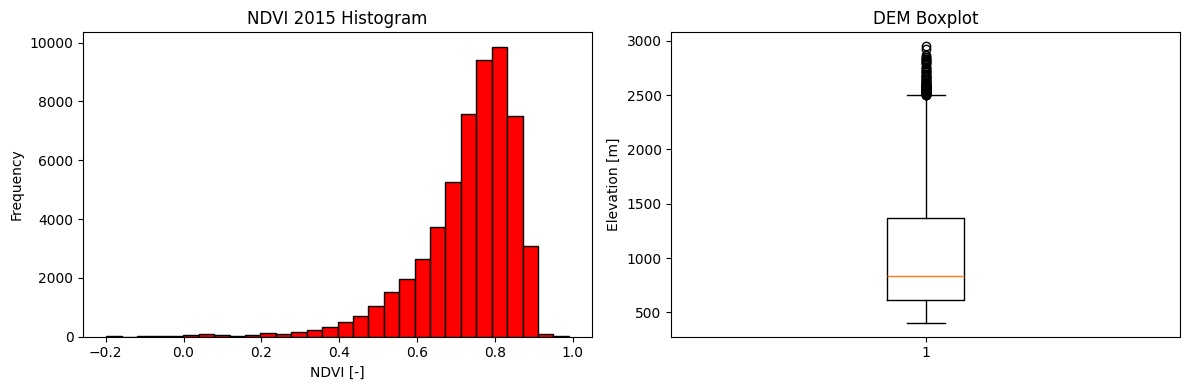

In [22]:
# we can also plot only the values by themselves with already introduced functions
# --- Histogram and Boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # subplots(1,2, ...) creates subplots with (1) row and (2) columns for a total of 2 plots!

# Histogram of NDVI
axes[0].hist(ndvi_2015.values.flatten(),         # axes[0] is the first subplot (index 0), and later, axes[1] is the second
             bins=30,                            # How many classes (bins)
             color="red",
             edgecolor="black")
axes[0].set_title("NDVI 2015 Histogram")
axes[0].set_xlabel("NDVI [-]")
axes[0].set_ylabel("Frequency")

# Boxplot of DEM
axes[1].boxplot(dem.values.flatten()[~np.isnan(dem.values.flatten())])  # only works without NaN, explanation above
axes[1].set_title("DEM Boxplot")
axes[1].set_ylabel("Elevation [m]")

plt.tight_layout()
plt.show()

You can also plot multiple boxplots side-by-side. This is useful when you want to compare the distributions of e.g. two different years, or of two (or more) different classes.

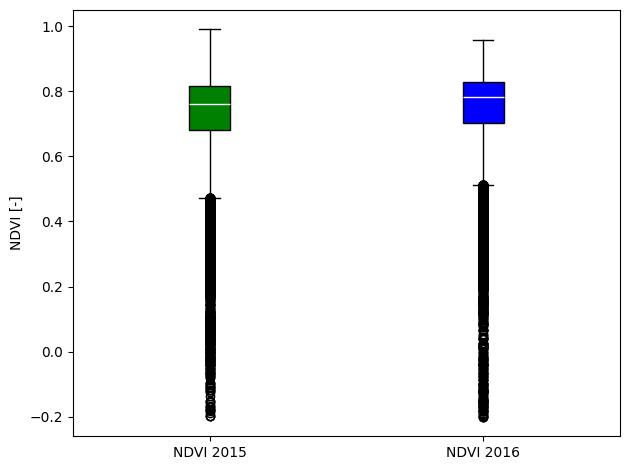

In [23]:
# Combining data sources. The data (without NaN) are stored in the list called bp_data.
bp_data = [
    ndvi_2015.values.flatten()[~np.isnan(ndvi_2015.values.flatten())],
    ndvi_2016.values.flatten()[~np.isnan(ndvi_2016.values.flatten())]
]

# Defining which labels to be plotted on the x-axis
labels = [
    "NDVI 2015",
    "NDVI 2016"
]
# Defining the colors for the boxplot boxes
colors = [
    'green',
    'blue'
]


# Plot
fig, ax = plt.subplots()
bplot = ax.boxplot(
    bp_data,
    tick_labels=labels,
    patch_artist=True
)

# Fill boxes with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
# Change median line colors to "white"
for patch, color in zip(bplot['medians'], colors):
    patch.set_color('white')

ax.set_ylabel("NDVI [-]")
    
plt.tight_layout()
plt.show()

### Operations
Images/raster objects in `xarray` format can be multiplied, subtracted, added, ... like a matrix or data.frame. The requirements for these operations are:
- same spatial resolution
- same spatial extent

> We took care of that in the preparation of the files

#### Examples II

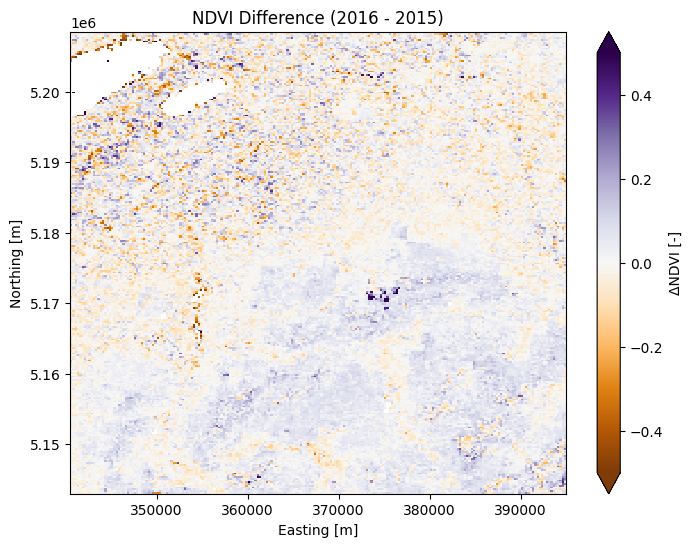

In [24]:
# --- NDVI Difference (2016 - 2015) ---
ndvi_diff = ndvi_2016 - ndvi_2015


# the plot
fig, ax = plt.subplots(figsize=(8, 6))
ndvi_diff.plot(
    ax=ax,
    cmap='PuOr',     # colormap examples: https://matplotlib.org/stable/users/explain/colors/colormaps.html#diverging
    vmin=-0.5,
    vmax=0.5,
    cbar_kwargs={"label": "ΔNDVI [-]"}
)
ax.set_title("NDVI Difference (2016 - 2015)")
ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")
plt.show()

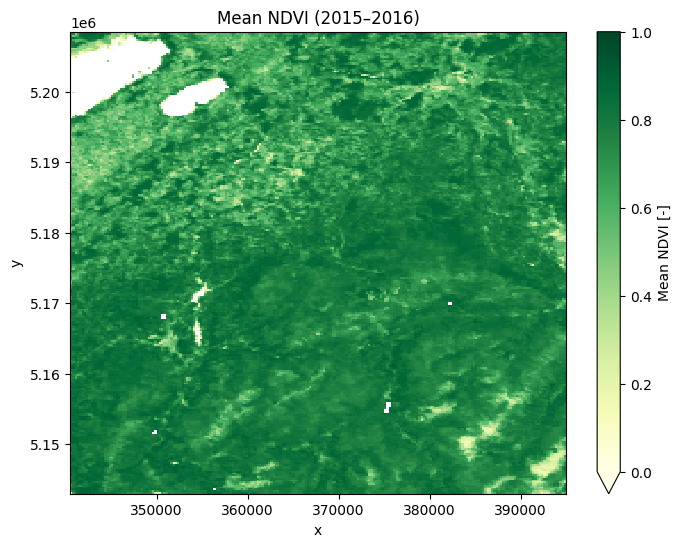

In [25]:
# --- NDVI Mean ---
ndvi_mean = (ndvi_2015 + ndvi_2016) / 2
# or for multiple rasters as follows:
# ndvi_mean = xr.concat([ndvi_2015, ndvi_2016], dim="time").mean(dim="time", skipna=True)

fig, ax = plt.subplots(figsize=(8, 6))
ndvi_mean.plot(
    ax=ax,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Mean NDVI [-]"}
)
ax.set_title("Mean NDVI (2015–2016)")
# ax.axis("off")
plt.show()

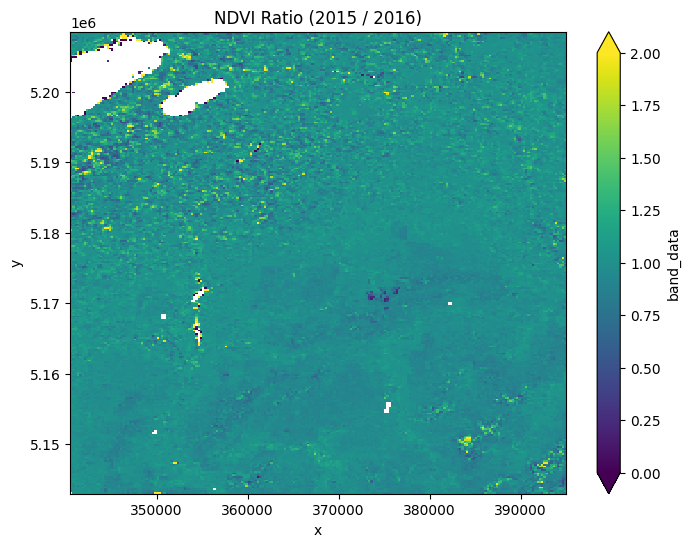

In [26]:
# --- Ratio ---
ndvi_ratio = ndvi_2015 / ndvi_2016


fig, ax = plt.subplots(figsize=(8, 6))
ndvi_ratio.plot(ax=ax,
                cmap="viridis",
                vmin=0,
                vmax=2)
ax.set_title("NDVI Ratio (2015 / 2016)")
plt.show()

## Tasks

1. Question: Are there differences in NDVI between different elevations? You expand on the basic example by defining elevation intervals (optimally just two for a start) and display differences in NDVI for the two classes. Choose two or more years for the NDVI data. The years 2015 to 2018 are available. 

2. Question: Are the changes in NDVI from one to another year per certain type of land use (MCD12Q1) the same for different elevation classes, or are there differences based on the elevation classes? You combine e.g. land use and elevation classes to study this question for the dry summers. You should define your question and are free to also use, e.g., exposition (aspect), by using multiple conditions. The ones that are more advanced can combine three or more conditions. It is also possible to investigate whether the signal is always present (dry and moist summers; Do a quick research on the website of meteoswiss regarding which summers were rather dry or wet) or more pronounced in dry summers.

3. You can choose between Jura and Fribourg for your analysis. Those of you who are fast, can do it for both.


**Mandatory processing steps:**

- Load the datasets and make sure you obtain a `xarray.DataArray` with only two dimensions (-> [Data-preparation](#Opening-and-accessing-data)). Follow the code example in [Loading-multiple-datasets](#Loading-multiple-datasets).
- Set NDVI values to NaN if outside meaningful range (x < 0 and x > 1); use `.where()` to achieve this.
    - for each of the NDVI files individually
- Create boxplots showcasing the different years against each other (all pixels for the individual files)
    - do not forget to remove the `NaN` values for the boxplots (-> [NaN-removal](#Histogram-and-Boxplot))
- Select values by elevation range (you can select other elevation ranges than those indicated below!)
    - Use the NDVI data of interest as your main raster and use the `.where()` function with the DEM as additional raster(s) with conditionals for the elevation ranges:
        - e.g. 100 to 1000 m
        - e.g. 1000 to 3000 m
    - Do this for each of the NDVI files individually
    - Create boxplots showcasing the difference between elevation classes (same year)
    - Create boxplots showcasing the difference between years (same elevation classes)
        

# Lookup table: functions, objects, and arguments
- `import <library name>` - Imports (make available) a library and its functions
- `<xarray.DataSet>` - The object type after opening a raster file
- `<xarray.DataArray>` - A single band or layer of a dataset
  - `.squeeze()` - reduces dimensions of an array to the minimum - useful if only one layer exists --> 3D to 2D
  - `.where()` - applies a conditional/logical operation to select only pixels where the condition inside the parenthesis is met
      - `.where(<rasterX> CONDITION)` - The condition can be any logical operation like `> 5`; You can use a different raster for the condition than the one you apply this function to, e.g., `rasterA.where(rasterB <= 10)`
   
      - You can use multiple conditions, separated by either `&`(AND) or `|`(OR), e.g.:
   
          - `rasterA.where((rasterB <= 10) | (rasterA > 2))`


    - `.plot()` - built-in plotting functions of `xarray` -> [Plotting](#Plotting)
   
        - `vmin=` - minimum value for the color scale
        - `vmax=` - maximum value for the color scale
        - `cmap=` - colormap for the color scale (e.g.: "viridis", "PuOr", ...)
        - `cbar_kwargs={"label": "NDVI [-]"}` - various options to change the colorbar ("cbar"); here the label.
